In [10]:
vues = {
    'Lisa Rose': {
        'Shape of You': 25,
        'Blinding Lights': 32,
        'Levitating': 36,
        'Perfect': 35,
        'Flowers': 25,
        'As It Was': 30
    },
    'Gene Seymour': {
        'Shape of You': 30,
        'Blinding Lights': 35,
        'Levitating': 15,
        'Perfect': 50,
        'Flowers': 30,
        'As It Was': 30
    },
    'Michael Phillips': {
        'Shape of You': 25,
        'Blinding Lights': 30,
        'Perfect': 35,
        'As It Was': 40
    },
    'Claudia Puig': {
        'Blinding Lights': 35,
        'Levitating': 30,
        'As It Was': 45,
        'Perfect': 40,
        'Flowers': 25
    },
    'Mick LaSalle': {
        'Shape of You': 31,
        'Blinding Lights': 40,
        'Levitating': 20,
        'Perfect': 30,
        'Flowers': 20,
        'As It Was': 30
    },
    'Jack Matthews': {
        'Shape of You': 30,
        'Blinding Lights': 40,
        'As It Was': 30,
        'Perfect': 50,
        'Flowers': 30
    },
    'Toby': {
        'Blinding Lights': 45,
        'Flowers': 10,
        'Perfect': 40
    }
}


# **« Si deux chansons sont souvent écoutées ensemble, alors quelqu’un qui aime l’une aimera probablement l’autre. »**

## **1 - Simple visualisation**

In [ ]:
import math
import matplotlib.pyplot as plt

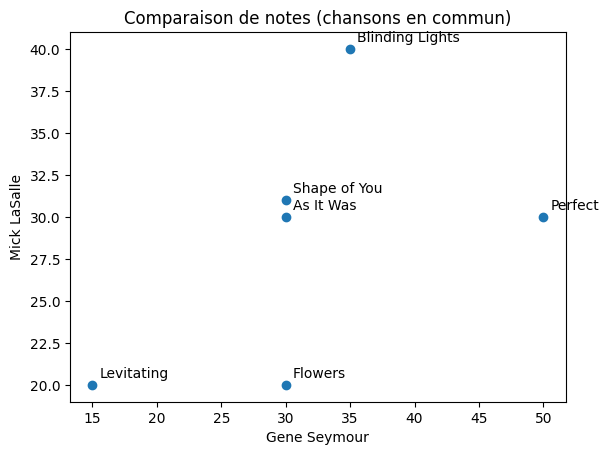

In [12]:
# Scatter des notes de deux critiques
u1, u2 = 'Gene Seymour', 'Mick LaSalle'
common = [m for m in vues[u1] if m in vues[u2]]
x2 = [vues[u1][m] for m in common]
y2 = [vues[u2][m] for m in common]

plt.figure()
plt.scatter(x2, y2)
for i, m in enumerate(common):
    plt.annotate(m, (x2[i], y2[i]), xytext=(5, 5), textcoords='offset points')
plt.xlabel(u1)
plt.ylabel(u2)
plt.title("Comparaison de notes (chansons en commun)")
plt.show()

## **2 - Mesures de similarité**

On implémente trois mesures courantes :
- **Euclidienne inversée** : plus la distance est petite, plus la similarité est grande.


In [13]:

def shared_items(prefs, p1, p2):
    """Retourne l'ensemble des items notés par p1 ET p2."""
    return {item for item in prefs[p1] if item in prefs[p2]}

def sim_distance(prefs, p1, p2):
    """Similarité euclidienne inversée entre p1 et p2 (∈ (0,1])."""
    si = shared_items(prefs, p1, p2)
    if not si:
        return 0
    sum_sq = sum((prefs[p1][it] - prefs[p2][it])**2 for it in si)
    return 1 / (1 + sum_sq)

In [18]:
# Petit test
print("Euclidienne inv.(Lisa, Gene) =", round(sim_distance(vues, 'Lisa Rose', 'Gene Seymour'), 3))

Euclidienne inv.(Lisa, Gene) = 0.001


## **3 - Utilisateurs les plus proches — `topMatches`**

Pour un utilisateur cible, on calcule la similarité avec tous les autres, on trie et on garde les **n meilleurs**.


In [19]:
def topMatches(prefs, person, n=5, similarity=sim_distance):
    scores = []
    for other in prefs:
        if other == person:
            continue
        s = similarity(prefs, person, other)
        scores.append((s, other))
    scores.sort(reverse=True, key=lambda x: x[0])
    return scores[:n]


In [20]:
print("Top matches (Lisa, Euclude) :", topMatches(vues, 'Lisa Rose', n=3, similarity=sim_distance))

Top matches (Lisa, Euclude) : [(0.009523809523809525, 'Michael Phillips'), (0.0033783783783783786, 'Claudia Puig'), (0.0029411764705882353, 'Jack Matthews')]


## 5 - Recommandations user-based — `getRecommendations`

On **pondère** la note des autres utilisateurs par leur similarité avec l'utilisateur cible, puis on **normalise**.
On ignore les similarités ≤ 0 et les films déjà notés par la personne cible.

In [22]:
def getRecommendations(prefs, person, similarity=sim_pearson):
    totals = {}
    simSums = {}
    for other in prefs:
        if other == person:
            continue
        sim = similarity(prefs, person, other)
        if sim <= 0:
            continue
        for item, rating in prefs[other].items():
            if item in prefs[person]:
                continue
            totals.setdefault(item, 0)
            simSums.setdefault(item, 0)
            totals[item] += rating * sim
            simSums[item] += sim
    rankings = [(totals[it]/simSums[it], it) for it in totals if simSums[it] != 0]
    rankings.sort(reverse=True, key=lambda x: x[0])
    return rankings

In [24]:
print("Recommandations pour Toby (Pearson) :", getRecommendations(vues, 'Toby', similarity=sim_distance))

Recommandations pour Toby (Pearson) : [(34.927755787562496, 'As It Was'), (28.09121364582034, 'Shape of You'), (25.23966753840188, 'Levitating')]


# **« Si deux personnes ont les mêmes goûts, alors l’une pourrait aimer ce que l’autre aime. »**

## 5 - Vue item-based

On transpose d'abord le dictionnaire `{user: {item: note}}` en `{item: {user: note}}`,
puis on applique **les mêmes fonctions** (`topMatches`, `getRecommendations`) du côté des items.

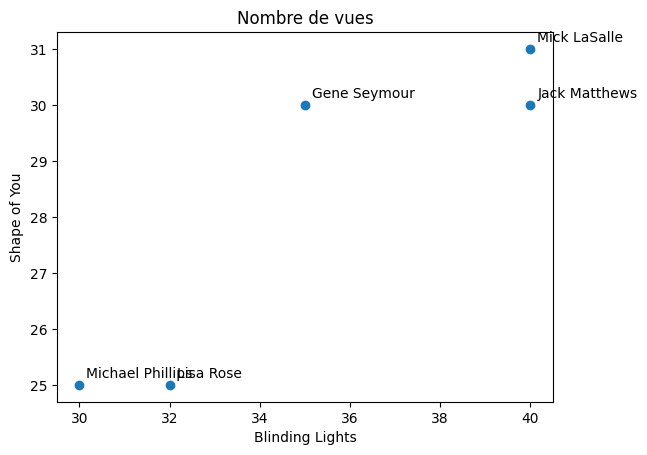

In [11]:
# Scatter 2 chansons
film_x, film_y = 'Blinding Lights', 'Shape of You'

xs, ys, labels = [], [], []
for user, ratings in vues.items():
    if film_x in ratings and film_y in ratings:
        xs.append(ratings[film_x])
        ys.append(ratings[film_y])
        labels.append(user)

plt.figure()
plt.scatter(xs, ys)
for i, label in enumerate(labels):
    plt.annotate(label, (xs[i], ys[i]), xytext=(5, 5), textcoords='offset points')
plt.xlabel(film_x)
plt.ylabel(film_y)
plt.title("Nombre de vues")
plt.show()

In [25]:

def transformPrefs(prefs):
    result = {}
    for person in prefs:
        for item, rating in prefs[person].items():
            result.setdefault(item, {})
            result[item][person] = rating
    return result

In [26]:
movies = transformPrefs(vues)

In [29]:
print("Films similaires à 'As It Was' (euclude) :")
print(topMatches(movies, 'As It Was', n=3, similarity=sim_distance))

Films similaires à 'Superman Returns' (euclude) :
[(0.003968253968253968, 'Shape of You'), (0.002325581395348837, 'Blinding Lights'), (0.0019011406844106464, 'Flowers')]


In [30]:
print("\nRecommandations item-based à partir de 'As It Was' :")
print(getRecommendations(movies, 'As It Was', similarity=sim_distance))


Recommandations item-based à partir de 'As It Was' :
[(31.541730441617243, 'Toby')]
